# Clasificación con LightGBM (LGBM) — Loan Prediction Dataset

Pipeline completo: EDA, preprocesamiento, entrenamiento y optimización de hiperparámetros para predecir si un solicitante de préstamo será aprobado (`Loan_Status`).

Dataset: https://github.com/shrikant-temburwar/Loan-Prediction-Dataset

## Parte 1: Carga y Exploración Inicial de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# El dataset original de Kaggle viene dividido en train/test sin la variable
# objetivo en test, por lo que para este ejercicio de clasificación supervisada
# usamos el conjunto de entrenamiento (que sí trae Loan_Status) como dataset base.
DATA_URL = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"
df = pd.read_csv(DATA_URL)
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Dimensiones del dataset:", df.shape)
df.info()

Dimensiones del dataset: (614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [4]:
# Descripción de variables numéricas y categóricas
display(df.describe())
display(df.describe(include="object"))

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


/tmp/ipykernel_6250/743831948.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [5]:
# Valores faltantes
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df[missing_df["missing"] > 0]

,missing,pct
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


In [6]:
# Detección de outliers mediante IQR para variables numéricas continuas
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers (límites IQR: [{lower:.1f}, {upper:.1f}])")

ApplicantIncome: 50 outliers (límites IQR: [-1498.8, 10171.2])
CoapplicantIncome: 18 outliers (límites IQR: [-3445.9, 5743.1])
LoanAmount: 39 outliers (límites IQR: [-2.0, 270.0])
Loan_Amount_Term: 88 outliers (límites IQR: [360.0, 360.0])


## Parte 2: Análisis Exploratorio de Datos (EDA)

In [7]:
# Estadísticas descriptivas de las variables numéricas
df[num_cols + ["Credit_History"]].agg(["mean", "median", "std", "min", "max"]).T

,mean,median,std,min,max
ApplicantIncome,5403.459283,3812.5,6109.041673,150.0,81000.0
CoapplicantIncome,1621.245798,1188.5,2926.248369,0.0,41667.0
LoanAmount,146.412162,128.0,85.587325,9.0,700.0
Loan_Amount_Term,342.000000,360.0,65.120410,12.0,480.0
Credit_History,0.842199,1.0,0.364878,0.0,1.0


In [8]:
# Distribución de variables categóricas
cat_cols = ["Gender", "Married", "Dependents", "Education",
            "Self_Employed", "Property_Area", "Loan_Status"]
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False, normalize=True).round(3))


Gender:
Gender
Male      0.796
Female    0.182
NaN       0.021
Name: proportion, dtype: float64

Married:
Married
Yes    0.648
No     0.347
NaN    0.005
Name: proportion, dtype: float64

Dependents:
Dependents
0      0.562
1      0.166
2      0.164
3+     0.083
NaN    0.024
Name: proportion, dtype: float64

Education:
Education
Graduate        0.782
Not Graduate    0.218
Name: proportion, dtype: float64

Self_Employed:
Self_Employed
No     0.814
Yes    0.134
NaN    0.052
Name: proportion, dtype: float64

Property_Area:
Property_Area
Semiurban    0.379
Urban        0.329
Rural        0.292
Name: proportion, dtype: float64

Loan_Status:
Loan_Status
Y    0.687
N    0.313
Name: proportion, dtype: float64


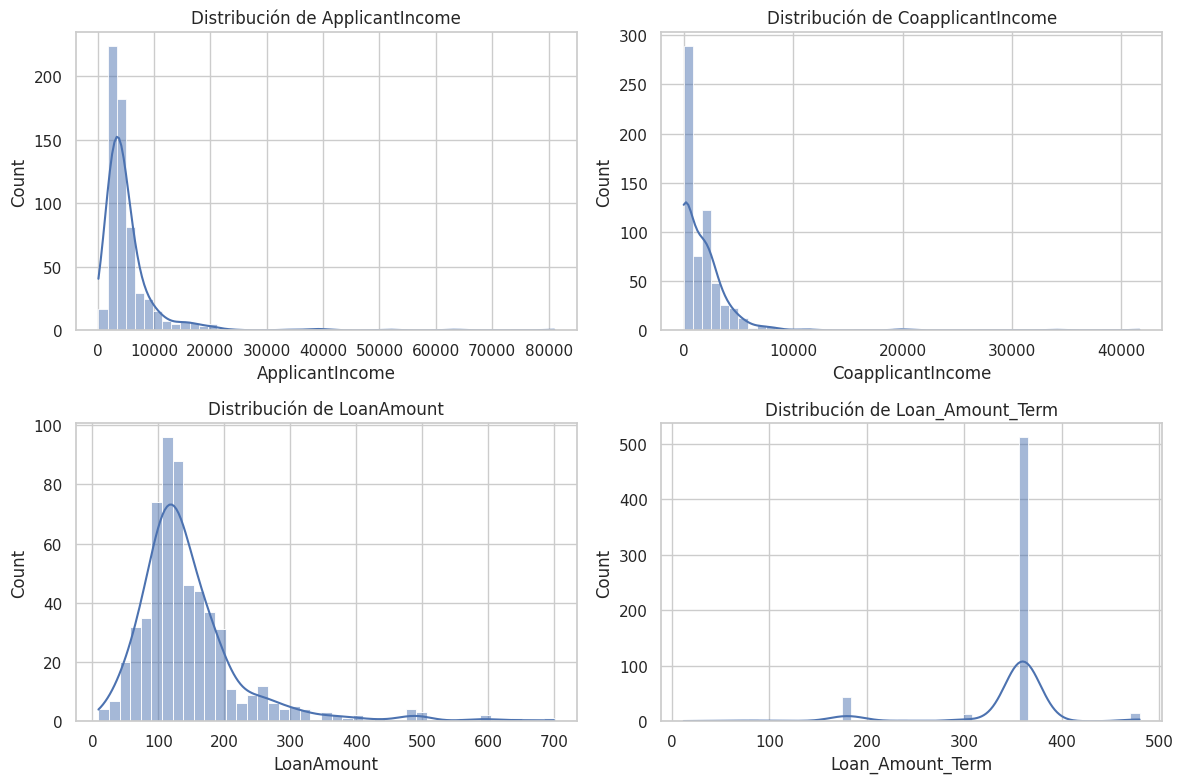

In [9]:
# Histogramas de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

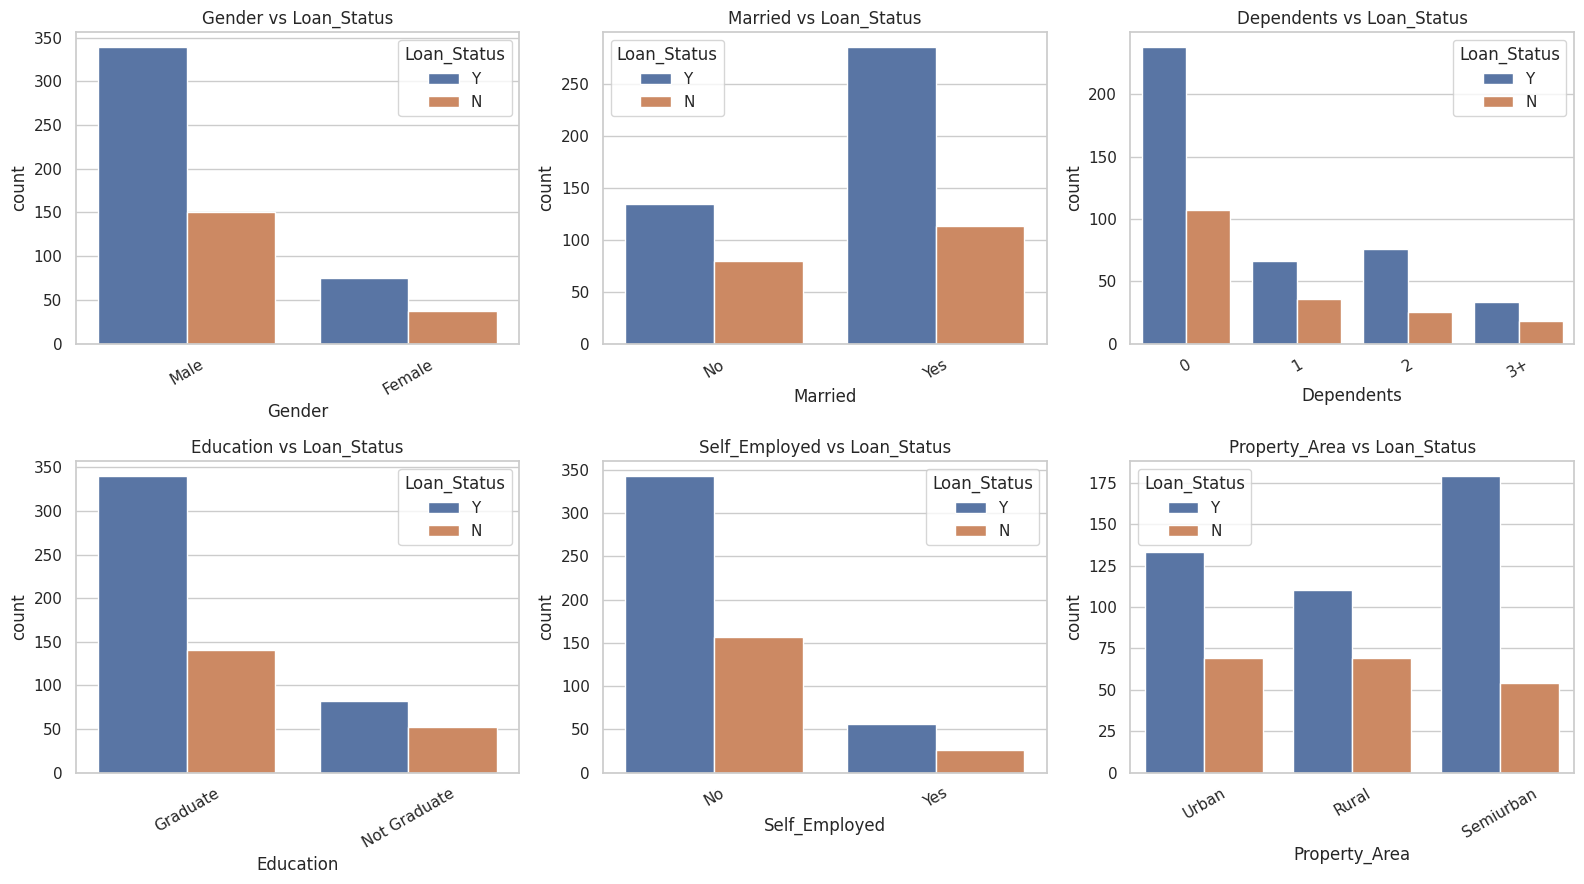

In [10]:
# Gráficos de barras de variables categóricas vs Loan_Status
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), cat_cols[:-1]):
    sns.countplot(data=df, x=col, hue="Loan_Status", ax=ax)
    ax.set_title(f"{col} vs Loan_Status")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

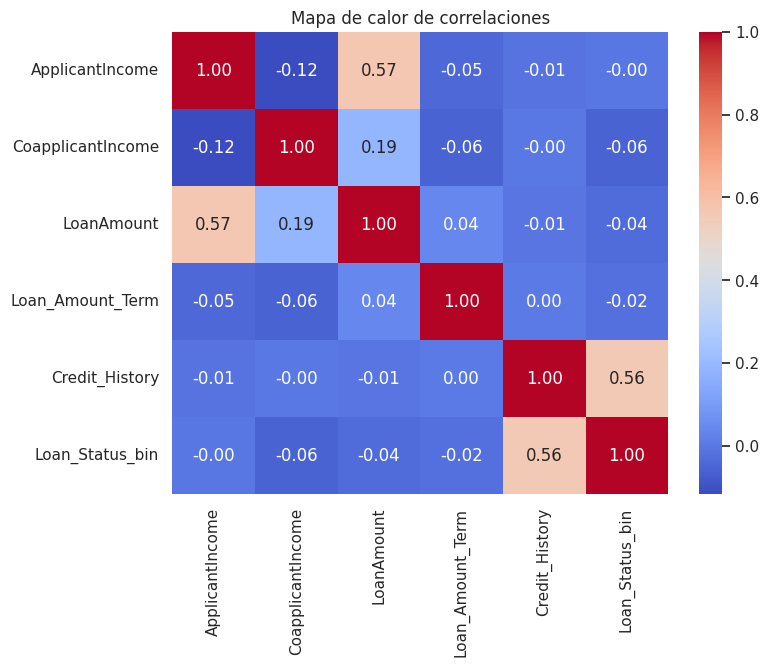

In [11]:
# Mapa de calor de correlaciones (variables numéricas + target codificado)
corr_df = df.copy()
corr_df["Loan_Status_bin"] = corr_df["Loan_Status"].map({"Y": 1, "N": 0})
corr_df["Credit_History"] = corr_df["Credit_History"]
corr_cols = num_cols + ["Credit_History", "Loan_Status_bin"]
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de calor de correlaciones")
plt.show()

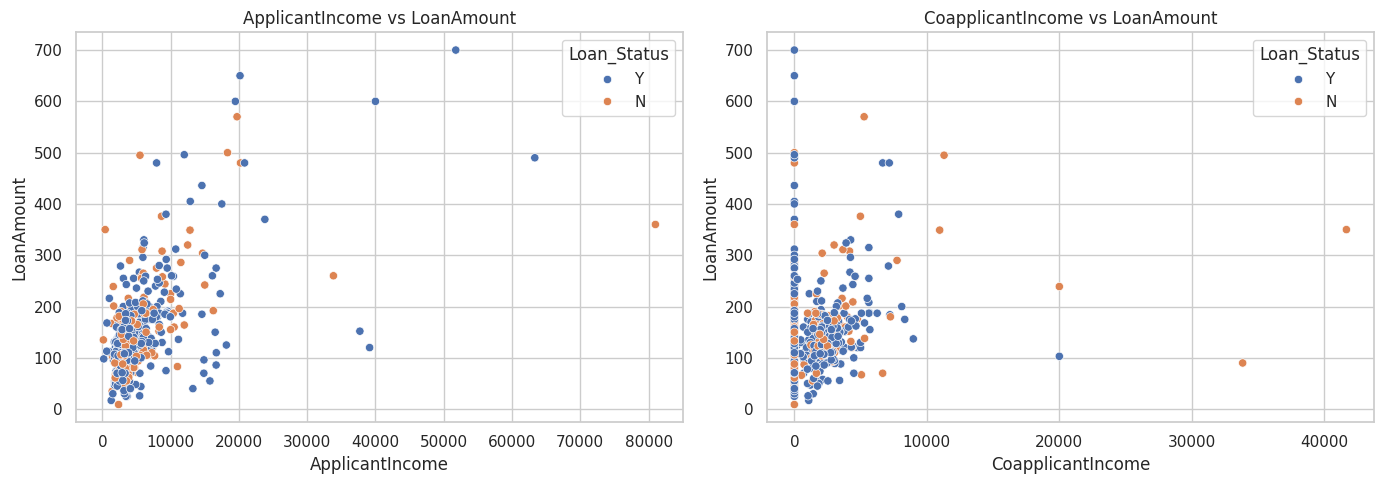

In [12]:
# Gráficos de dispersión entre variables numéricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="ApplicantIncome", y="LoanAmount", hue="Loan_Status", ax=axes[0])
axes[0].set_title("ApplicantIncome vs LoanAmount")
sns.scatterplot(data=df, x="CoapplicantIncome", y="LoanAmount", hue="Loan_Status", ax=axes[1])
axes[1].set_title("CoapplicantIncome vs LoanAmount")
plt.tight_layout()
plt.show()

In [13]:
# Tratamiento de valores faltantes:
# - Categóricas: moda
# - Numéricas: mediana (más robusta ante outliers)
df_clean = df.copy()
for col in ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
for col in ["LoanAmount", "Loan_Amount_Term"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Valores faltantes restantes:", df_clean.isnull().sum().sum())

Valores faltantes restantes: 0


In [14]:
# Tratamiento de outliers: capping (winsorización) por IQR en variables continuas
for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

df_clean[num_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,614.000000,614.000000
mean,4617.111564,1419.702231,137.365635,342.410423
std,2479.851729,1624.605892,55.779749,64.428629
min,150.000000,0.000000,9.000000,12.000000
25%,2877.500000,0.000000,100.250000,360.000000
50%,3812.500000,1188.500000,128.000000,360.000000
75%,5795.000000,2297.250000,164.750000,360.000000
max,10171.250000,5743.125000,261.500000,480.000000


## Parte 3: Preprocesamiento de Datos

In [15]:
# Eliminamos el identificador y separamos features / target
df_model = df_clean.drop(columns=["Loan_ID"])
X = df_model.drop(columns=["Loan_Status"])
y = df_model["Loan_Status"].map({"Y": 1, "N": 0})

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()
print("Categóricas:", categorical_features)
print("Numéricas:", numerical_features)

Categóricas: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numéricas: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


/tmp/ipykernel_6250/2732636192.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (491, 11)  Test: (123, 11)


## Parte 4: Implementación de LightGBM (LGBM)

In [18]:
def evaluate(model, X_test, y_test, label):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }
    print(f"--- {label} ---")
    for k, v in metrics.items():
        print(f"{k:>10}: {v:.4f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred))
    return metrics, y_pred, y_proba

In [19]:
# Modelo base con hiperparámetros básicos
base_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(random_state=42, verbose=-1, n_jobs=1)),
])

base_pipeline.fit(X_train, y_train)
base_metrics, base_pred, base_proba = evaluate(base_pipeline, X_test, y_test, "LGBM base")

--- LGBM base ---
  accuracy: 0.8293
 precision: 0.8721
    recall: 0.8824
        f1: 0.8772
   roc_auc: 0.7957

Classification report:
               precision    recall  f1-score   support

           0       0.73      0.71      0.72        38
           1       0.87      0.88      0.88        85

    accuracy                           0.83       123
   macro avg       0.80      0.80      0.80       123
weighted avg       0.83      0.83      0.83       123



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


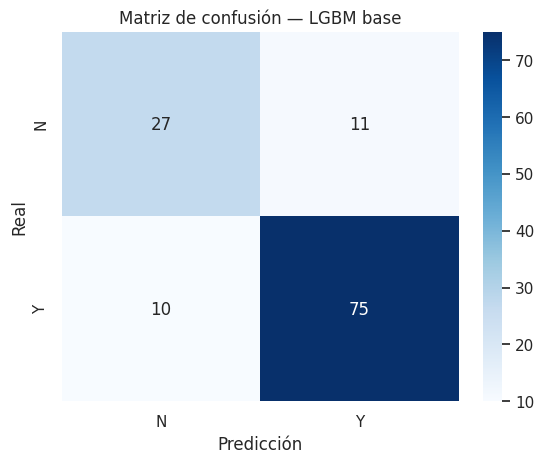

In [20]:
# Matriz de confusión del modelo base
cm = confusion_matrix(y_test, base_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["N", "Y"], yticklabels=["N", "Y"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión — LGBM base")
plt.show()

In [21]:
# Optimización de hiperparámetros con GridSearchCV
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__num_leaves": [15, 31],
    "classifier__learning_rate": [0.01, 0.1],
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor ROC-AUC (CV):", grid_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Mejores hiperparámetros: {'classifier__learning_rate': 0.01, 'classifier__n_estimators': 200, 'classifier__num_leaves': 15}
Mejor ROC-AUC (CV): 0.7327459439925278


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [22]:
best_model = grid_search.best_estimator_
tuned_metrics, tuned_pred, tuned_proba = evaluate(best_model, X_test, y_test, "LGBM optimizado")

--- LGBM optimizado ---
  accuracy: 0.8455
 precision: 0.8300
    recall: 0.9765
        f1: 0.8973
   roc_auc: 0.7807

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.55      0.69        38
           1       0.83      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.87      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [23]:
# Comparación entre el modelo base y el modelo optimizado
comparison = pd.DataFrame([base_metrics, tuned_metrics], index=["LGBM base", "LGBM optimizado"])
comparison_styled = comparison.round(4)
comparison_styled

,accuracy,precision,recall,f1,roc_auc
LGBM base,0.8293,0.8721,0.8824,0.8772,0.7957
LGBM optimizado,0.8455,0.8300,0.9765,0.8973,0.7807


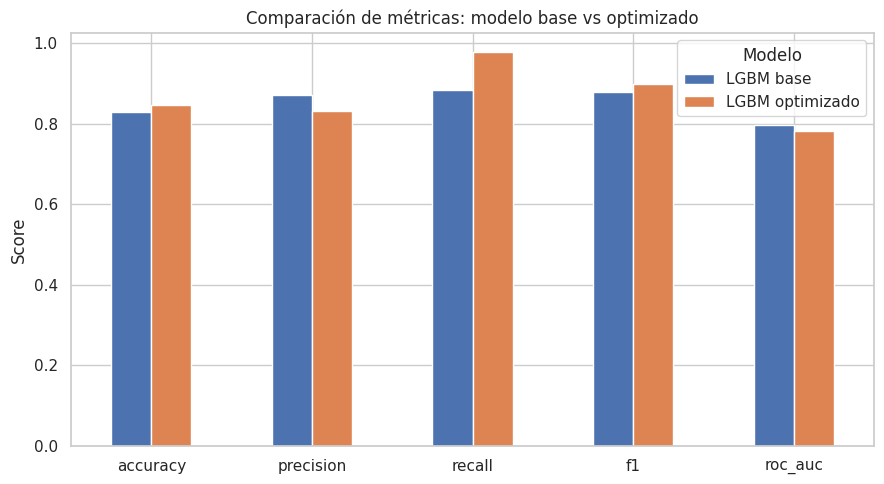

In [24]:
comparison.T.plot(kind="bar", figsize=(9, 5), rot=0)
plt.ylabel("Score")
plt.title("Comparación de métricas: modelo base vs optimizado")
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

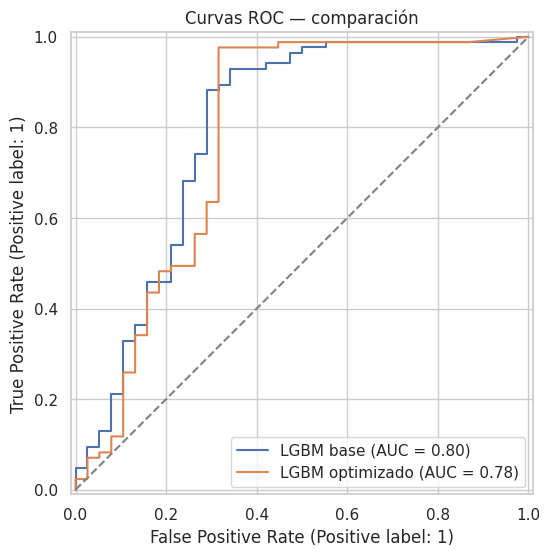

In [25]:
# Curvas ROC comparadas
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, base_proba, name="LGBM base", ax=ax)
RocCurveDisplay.from_predictions(y_test, tuned_proba, name="LGBM optimizado", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("Curvas ROC — comparación")
plt.show()

## Conclusiones

- El conjunto de datos presenta valores faltantes principalmente en variables categóricas (`Gender`, `Married`, `Dependents`, `Self_Employed`) y numéricas (`LoanAmount`, `Loan_Amount_Term`, `Credit_History`), tratados mediante imputación por moda/mediana.
- `Credit_History` muestra la correlación más fuerte con la variable objetivo, consistente con su importancia esperada en la aprobación de préstamos.
- La optimización de hiperparámetros mediante `GridSearchCV` (validación cruzada de 5 folds, métrica ROC-AUC) permite comparar el modelo base contra el modelo afinado y seleccionar la combinación de `n_estimators`, `num_leaves`, `max_depth` y `learning_rate` que maximiza el desempeño en validación.